In [4]:
import os
import shutil
from tqdm import tqdm

BASE_DIR = "../data"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")
OUT_DIR = os.path.join(BASE_DIR, "images")

os.makedirs(OUT_DIR, exist_ok=True)

def merge_split(split_dir, out_dir):
    classes = sorted(os.listdir(split_dir))
    for cls in classes:
        cls_path = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_path):
            continue

        out_cls_path = os.path.join(out_dir, cls)
        os.makedirs(out_cls_path, exist_ok=True)

        for fname in tqdm(os.listdir(cls_path), desc=f"Merging {cls} from {split_dir}"):
            src = os.path.join(cls_path, fname)
            dst = os.path.join(out_cls_path, fname)

            # avoid overwriting duplicates by renaming
            if os.path.exists(dst):
                base, ext = os.path.splitext(fname)
                i = 1
                while True:
                    new_name = f"{base}_{i}{ext}"
                    dst = os.path.join(out_cls_path, new_name)
                    if not os.path.exists(dst):
                        break
                    i += 1

            shutil.copy2(src, dst)

# Merge both train and test
merge_split(TRAIN_DIR, OUT_DIR)
merge_split(TEST_DIR, OUT_DIR)

print("✅ Dataset merged into:", OUT_DIR)


Merging Akarna_Dhanurasana from ../data\train: 100%|██████████| 60/60 [00:00<00:00, 78.32it/s]
Merging Bharadvajas_Twist_pose_or_Bharadvajasana_I_ from ../data\train: 100%|██████████| 57/57 [00:00<00:00, 74.82it/s]
Merging Boat_Pose_or_Paripurna_Navasana_ from ../data\train: 100%|██████████| 272/272 [00:03<00:00, 71.40it/s]
Merging Bound_Angle_Pose_or_Baddha_Konasana_ from ../data\train: 100%|██████████| 190/190 [00:02<00:00, 76.94it/s]
Merging Bow_Pose_or_Dhanurasana_ from ../data\train: 100%|██████████| 151/151 [00:01<00:00, 76.28it/s]
Merging Bridge_Pose_or_Setu_Bandha_Sarvangasana_ from ../data\train: 100%|██████████| 174/174 [00:02<00:00, 79.77it/s]
Merging Camel_Pose_or_Ustrasana_ from ../data\train: 100%|██████████| 223/223 [00:03<00:00, 65.93it/s]
Merging Cat_Cow_Pose_or_Marjaryasana_ from ../data\train: 100%|██████████| 296/296 [00:04<00:00, 68.94it/s]
Merging Chair_Pose_or_Utkatasana_ from ../data\train: 100%|██████████| 215/215 [00:03<00:00, 69.93it/s]
Merging Child_Pose_or_

✅ Dataset merged into: ../data\images


In [5]:
import os

BASE_DIR = "../data/images"

class_counts = {}
for cls in sorted(os.listdir(BASE_DIR)):
    cls_path = os.path.join(BASE_DIR, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
        class_counts[cls] = count

# Print counts nicely
for cls, count in class_counts.items():
    print(f"{cls}: {count} images")

print("\nTotal images:", sum(class_counts.values()))


Akarna_Dhanurasana: 73 images
Bharadvajas_Twist_pose_or_Bharadvajasana_I_: 69 images
Boat_Pose_or_Paripurna_Navasana_: 339 images
Bound_Angle_Pose_or_Baddha_Konasana_: 239 images
Bow_Pose_or_Dhanurasana_: 193 images
Bridge_Pose_or_Setu_Bandha_Sarvangasana_: 216 images
Camel_Pose_or_Ustrasana_: 276 images
Cat_Cow_Pose_or_Marjaryasana_: 374 images
Chair_Pose_or_Utkatasana_: 275 images
Child_Pose_or_Balasana_: 257 images
Cobra_Pose_or_Bhujangasana_: 698 images
Cockerel_Pose: 131 images
Corpse_Pose_or_Savasana_: 288 images
Cow_Face_Pose_or_Gomukhasana_: 279 images
Crane_(Crow)_Pose_or_Bakasana_: 200 images
Dolphin_Plank_Pose_or_Makara_Adho_Mukha_Svanasana_: 44 images
Dolphin_Pose_or_Ardha_Pincha_Mayurasana_: 60 images
Downward-Facing_Dog_pose_or_Adho_Mukha_Svanasana_: 138 images
Eagle_Pose_or_Garudasana_: 109 images
Eight-Angle_Pose_or_Astavakrasana_: 106 images
Extended_Puppy_Pose_or_Uttana_Shishosana_: 68 images
Extended_Revolved_Side_Angle_Pose_or_Utthita_Parsvakonasana_: 142 images
Ext

C:\Users\Harsh\AppData\Local\Temp\ipykernel_22204\713774613.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


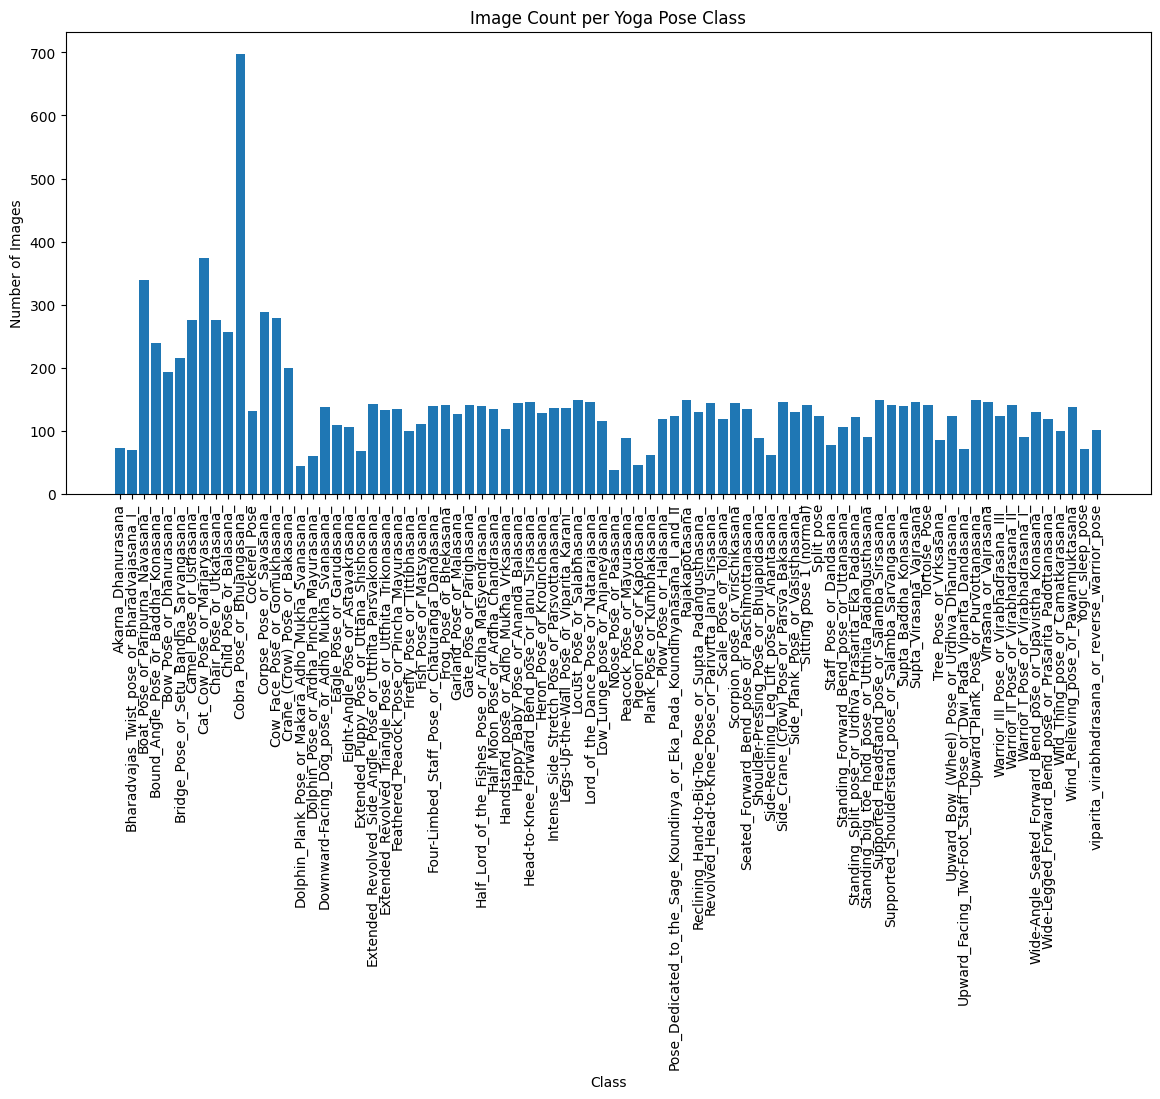

In [6]:
import os
import matplotlib.pyplot as plt


class_counts = {}
for cls in sorted(os.listdir(BASE_DIR)):
    cls_path = os.path.join(BASE_DIR, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
        class_counts[cls] = count

# Plot
plt.figure(figsize=(14,6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Image Count per Yoga Pose Class")
plt.tight_layout()
plt.show()


Classes with < 50 images: 3
Classes with 100–150 images: 52
Classes with > 150 images: 12


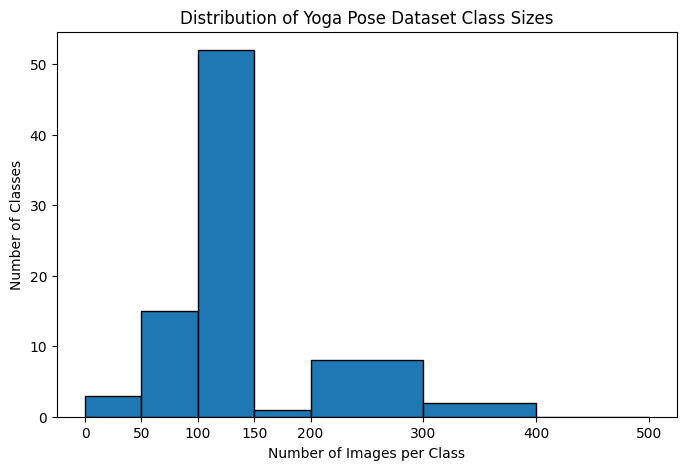

In [7]:
import os
import matplotlib.pyplot as plt


class_counts = []
class_labels = []

for cls in sorted(os.listdir(BASE_DIR)):
    cls_path = os.path.join(BASE_DIR, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
        class_counts.append(count)
        class_labels.append(cls)

# --- Summary buckets ---
less_than_50 = sum(1 for c in class_counts if c < 50)
between_100_150 = sum(1 for c in class_counts if 100 <= c <= 150)
greater_than_150 = sum(1 for c in class_counts if c > 150)

print(f"Classes with < 50 images: {less_than_50}")
print(f"Classes with 100–150 images: {between_100_150}")
print(f"Classes with > 150 images: {greater_than_150}")

# --- Histogram plot ---
plt.figure(figsize=(8,5))
plt.hist(class_counts, bins=[0,50,100,150,200,300,400,500], edgecolor='black')
plt.xlabel("Number of Images per Class")
plt.ylabel("Number of Classes")
plt.title("Distribution of Yoga Pose Dataset Class Sizes")
plt.xticks([0,50,100,150,200,300,400,500])
plt.show()


In [8]:
import os
import random
import shutil


# Set seed for reproducibility
random.seed(42)

for cls in sorted(os.listdir(BASE_DIR)):
    cls_path = os.path.join(BASE_DIR, cls)
    if not os.path.isdir(cls_path):
        continue

    files = [f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))]
    count = len(files)

    if count < 50:
        # Delete entire class
        print(f"🗑️ Deleting class {cls} (only {count} images)")
        shutil.rmtree(cls_path)

    elif count > 150:
        # Downsample to 150
        print(f"⚖️ Reducing class {cls} from {count} → 150 images")
        to_delete = random.sample(files, count - 150)
        for fname in to_delete:
            os.remove(os.path.join(cls_path, fname))

    else:
        # Between 50–150 → keep as is
        print(f"✅ Keeping class {cls} ({count} images)")

print("🎯 Dataset balancing complete!")


✅ Keeping class Akarna_Dhanurasana (73 images)
✅ Keeping class Bharadvajas_Twist_pose_or_Bharadvajasana_I_ (69 images)
⚖️ Reducing class Boat_Pose_or_Paripurna_Navasana_ from 339 → 150 images
⚖️ Reducing class Bound_Angle_Pose_or_Baddha_Konasana_ from 239 → 150 images
⚖️ Reducing class Bow_Pose_or_Dhanurasana_ from 193 → 150 images
⚖️ Reducing class Bridge_Pose_or_Setu_Bandha_Sarvangasana_ from 216 → 150 images
⚖️ Reducing class Camel_Pose_or_Ustrasana_ from 276 → 150 images
⚖️ Reducing class Cat_Cow_Pose_or_Marjaryasana_ from 374 → 150 images
⚖️ Reducing class Chair_Pose_or_Utkatasana_ from 275 → 150 images
⚖️ Reducing class Child_Pose_or_Balasana_ from 257 → 150 images
⚖️ Reducing class Cobra_Pose_or_Bhujangasana_ from 698 → 150 images
✅ Keeping class Cockerel_Pose (131 images)
⚖️ Reducing class Corpse_Pose_or_Savasana_ from 288 → 150 images
⚖️ Reducing class Cow_Face_Pose_or_Gomukhasana_ from 279 → 150 images
⚖️ Reducing class Crane_(Crow)_Pose_or_Bakasana_ from 200 → 150 images
🗑️ 

C:\Users\Harsh\AppData\Local\Temp\ipykernel_22204\2572220927.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


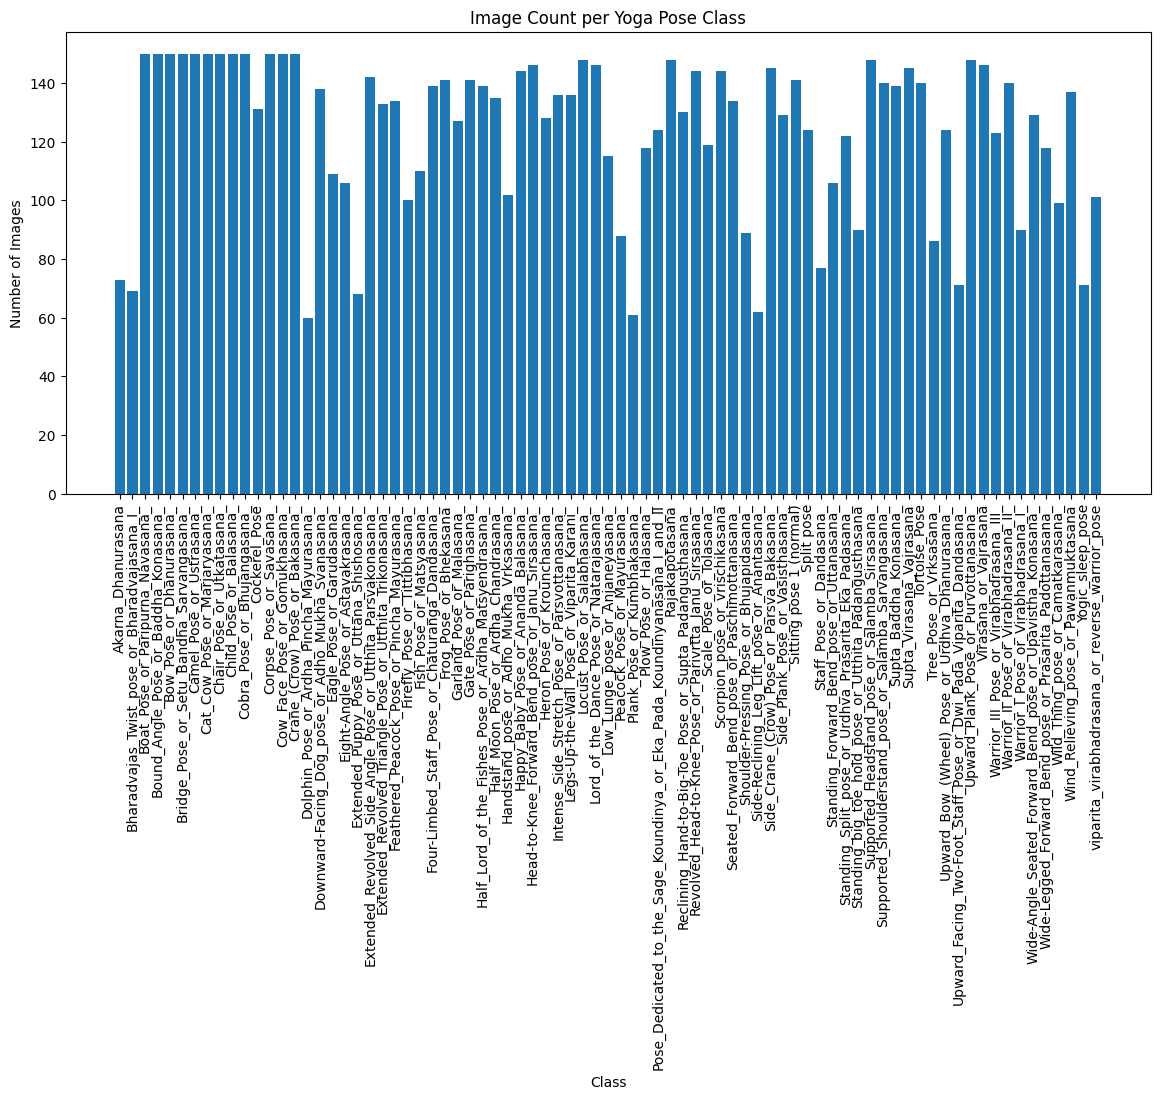

In [9]:
class_counts = {}
for cls in sorted(os.listdir(BASE_DIR)):
    cls_path = os.path.join(BASE_DIR, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
        class_counts[cls] = count

# Plot
plt.figure(figsize=(14,6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Image Count per Yoga Pose Class")
plt.tight_layout()
plt.show()

Classes with < 50 images: 0
Classes with 100–150 images: 64
Classes with > 150 images: 0


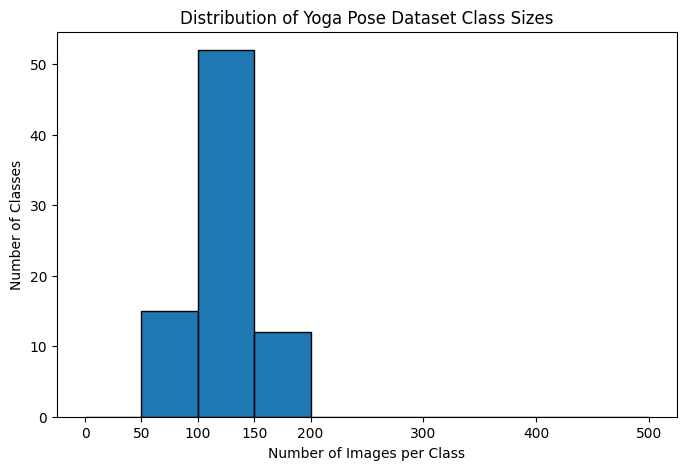

In [11]:
class_counts = []
class_labels = []

for cls in sorted(os.listdir(BASE_DIR)):
    cls_path = os.path.join(BASE_DIR, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
        class_counts.append(count)
        class_labels.append(cls)

# --- Summary buckets ---
less_than_50 = sum(1 for c in class_counts if c < 50)
between_100_150 = sum(1 for c in class_counts if 100 <= c <= 150)
greater_than_150 = sum(1 for c in class_counts if c > 150)

print(f"Classes with < 50 images: {less_than_50}")
print(f"Classes with 100–150 images: {between_100_150}")
print(f"Classes with > 150 images: {greater_than_150}")

# --- Histogram plot ---
plt.figure(figsize=(8,5))
plt.hist(class_counts, bins=[0,50,100,150,200,300,400,500], edgecolor='black')
plt.xlabel("Number of Images per Class")
plt.ylabel("Number of Classes")
plt.title("Distribution of Yoga Pose Dataset Class Sizes")
plt.xticks([0,50,100,150,200,300,400,500])
plt.show()
